<a href="https://colab.research.google.com/github/sabharwal-monish/Deep-Learning-Tensor-Flow/blob/main/cnn_cifar10_small_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
X_train.shape


(50000, 32, 32, 3)

In [6]:
y_train.shape

(50000, 1)

In [7]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [8]:
y_train = y_train.reshape((-1,))

In [9]:
y_test = y_test.reshape((-1,))

In [10]:
y_train[:4]

array([6, 9, 9, 4], dtype=uint8)

In [15]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [16]:
def plot_sample(X, y, index):
  plt.figure(figsize=(15,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

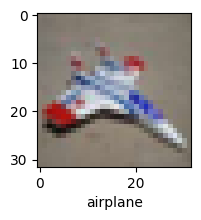

In [17]:
plot_sample(X_train, y_train, 30)

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [20]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.5213 - loss: 1.3420
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 41ms/step - accuracy: 0.6220 - loss: 1.0717
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 44ms/step - accuracy: 0.6750 - loss: 0.9389
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.7051 - loss: 0.8560
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7256 - loss: 0.7892
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 43ms/step - accuracy: 0.7450 - loss: 0.7365
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.7648 - loss: 0.6846
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.7781 - loss: 0.6428
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7872 - loss: 0.6051
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.8001 - loss: 0.5668


In [24]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7062 - loss: 0.9047


[0.9243192672729492, 0.7031000256538391]

In [25]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([[2.1950460e-04, 4.5424556e-05, 2.1340088e-03, 8.8751167e-01,
        1.8127644e-04, 9.5601849e-02, 1.2609465e-02, 1.2578513e-04,
        1.5156559e-03, 5.5246823e-05],
       [5.0460235e-03, 1.3175447e-02, 2.1518365e-06, 4.9074757e-08,
        8.4308809e-08, 1.5812047e-09, 4.4883675e-10, 2.2681627e-08,
        9.8141116e-01, 3.6501698e-04],
       [9.8764867e-02, 4.1504359e-01, 3.2962062e-03, 2.8684416e-03,
        1.4428810e-04, 3.7844153e-04, 9.0280526e-05, 2.5064403e-03,
        4.4554225e-01, 3.1365290e-02],
       [9.7115904e-01, 6.2066386e-04, 1.1637437e-02, 1.2290593e-03,
        3.2800350e-03, 5.0231167e-05, 2.6193737e-05, 8.9164969e-05,
        1.1587005e-02, 3.2122803e-04],
       [1.6638070e-07, 2.8027469e-04, 1.4002357e-01, 4.9197614e-02,
        4.6879587e-01, 8.8628463e-04, 3.4068906e-01, 2.5238026e-07,
        1.2698535e-04, 1.4480138e-08]], dtype=float32)

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

print('classification reort:\n', classification_report(y_test, y_classes))

classification reort:
               precision    recall  f1-score   support

           0       0.72      0.78      0.75      1000
           1       0.80      0.81      0.81      1000
           2       0.63      0.57      0.60      1000
           3       0.51      0.51      0.51      1000
           4       0.70      0.60      0.65      1000
           5       0.62      0.61      0.62      1000
           6       0.72      0.83      0.77      1000
           7       0.78      0.71      0.75      1000
           8       0.84      0.77      0.80      1000
           9       0.73      0.82      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000

